In [3]:
import os
from typing import Dict, List, Optional, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style
sns.set_theme(style="whitegrid")


# Data loading
def load_data(file_path: str) -> pd.DataFrame:
    """
    Load dataset from a CSV file.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)
    return df


# Column helper functions
def get_numeric_columns(df: pd.DataFrame) -> List[str]:
    """
    Return a list of numeric columns.
    """
    return df.select_dtypes(include=[np.number]).columns.tolist()


def get_categorical_columns(df: pd.DataFrame) -> List[str]:
    """
    Return a list of categorical columns.
    """
    return df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


# Basic dataset overview
def get_basic_info(df: pd.DataFrame) -> Dict[str, Union[tuple, List[str], pd.Series]]:
    """
    Return basic information about the dataset.
    """
    return {
        "shape": df.shape,
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes,
        "missing_values": df.isnull().sum().sort_values(ascending=False),
    }


def missing_value_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return missing value count and percentage for each column.
    """
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    summary = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    }).sort_values(by=["missing_count", "missing_percent"], ascending=False)

    return summary


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return summary statistics for numeric columns.
    """
    numeric_cols = get_numeric_columns(df)
    if not numeric_cols:
        return pd.DataFrame()

    return df[numeric_cols].describe().T


def categorical_summary(df: pd.DataFrame) -> Dict[str, pd.Series]:
    """
    Return value counts for each categorical column.
    """
    categorical_cols = get_categorical_columns(df)
    summary = {}

    for col in categorical_cols:
        summary[col] = df[col].value_counts(dropna=False)

    return summary


# Filtering
def filter_data(
    df: pd.DataFrame,
    filters: Optional[Dict[str, Union[str, int, float, bool, List[Union[str, int, float, bool]]]]] = None
) -> pd.DataFrame:
    """
    Filter the dataset using a dictionary of conditions.

    Example:
        filters = {"gender": "Male"}
        filters = {"city": ["New York", "Los Angeles"]}
    """
    filtered_df = df.copy()

    if filters is None:
        return filtered_df

    for column, value in filters.items():
        if column not in filtered_df.columns:
            raise KeyError(f"Column '{column}' not found in DataFrame.")

        if isinstance(value, list):
            filtered_df = filtered_df[filtered_df[column].isin(value)]
        else:
            filtered_df = filtered_df[filtered_df[column] == value]

    return filtered_df


# Plot saving/showing helper function
def _finalize_plot(save_path: Optional[str] = None, show: bool = True) -> None:
    """
    Finalize plot: save and/or show.
    """
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


# Plot functions
def plot_histogram(
    df: pd.DataFrame,
    column: str,
    bins: int = 30,
    kde: bool = True,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Plot histogram for a numeric column.
    """
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found.")
    if column not in get_numeric_columns(df):
        raise TypeError(f"Column '{column}' is not numeric.")

    plt.figure(figsize=(8, 5))
    sns.histplot(df[column].dropna(), bins=bins, kde=kde)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    _finalize_plot(save_path=save_path, show=show)


def plot_boxplot(
    df: pd.DataFrame,
    column: str,
    by: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Plot a boxplot for a numeric column.
    If 'by' is provided, group by that column.
    """
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found.")
    if column not in get_numeric_columns(df):
        raise TypeError(f"Column '{column}' is not numeric.")

    plt.figure(figsize=(8, 5))

    if by is None:
        sns.boxplot(x=df[column])
        plt.xlabel(column)
        plt.title(f"Boxplot of {column}")
    else:
        if by not in df.columns:
            raise KeyError(f"Grouping column '{by}' not found.")
        sns.boxplot(data=df, x=by, y=column)
        plt.xticks(rotation=45)
        plt.title(f"Boxplot of {column} by {by}")
        plt.xlabel(by)
        plt.ylabel(column)

    _finalize_plot(save_path=save_path, show=show)


def plot_countplot(
    df: pd.DataFrame,
    column: str,
    top_n: Optional[int] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Plot a countplot for a categorical column.
    If top_n is given, only plot the top N categories.
    """
    if column not in df.columns:
        raise KeyError(f"Column '{column}' not found.")

    counts = df[column].value_counts(dropna=False)

    if top_n is not None:
        allowed = counts.head(top_n).index
        plot_df = df[df[column].isin(allowed)].copy()
        order = plot_df[column].value_counts(dropna=False).index
    else:
        plot_df = df.copy()
        order = counts.index

    plt.figure(figsize=(10, 5))
    sns.countplot(data=plot_df, x=column, order=order)
    plt.title(f"Count Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    _finalize_plot(save_path=save_path, show=show)


def plot_scatter(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    hue: Optional[str] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Plot scatterplot between two numeric columns.
    """
    if x_col not in df.columns or y_col not in df.columns:
        raise KeyError("One or both selected columns were not found.")
    if x_col not in get_numeric_columns(df) or y_col not in get_numeric_columns(df):
        raise TypeError("Scatterplot requires both x_col and y_col to be numeric.")
    if hue is not None and hue not in df.columns:
        raise KeyError(f"Hue column '{hue}' not found.")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue)
    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    _finalize_plot(save_path=save_path, show=show)


def plot_correlation_heatmap(
    df: pd.DataFrame,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    Plot correlation heatmap for numeric columns.
    """
    numeric_cols = get_numeric_columns(df)
    if len(numeric_cols) < 2:
        raise ValueError("At least two numeric columns are required for a correlation heatmap.")

    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Heatmap")
    _finalize_plot(save_path=save_path, show=show)


# App-ready wrapper
def generate_plot(
    df: pd.DataFrame,
    plot_type: str,
    col1: Optional[str] = None,
    col2: Optional[str] = None,
    by: Optional[str] = None,
    hue: Optional[str] = None,
    bins: int = 30,
    top_n: Optional[int] = None,
    save_path: Optional[str] = None,
    show: bool = True
) -> None:
    """
    General wrapper for app use.

    Supported plot_type:
    - histogram
    - boxplot
    - countplot
    - scatter
    - correlation
    """
    plot_type = plot_type.lower()

    if plot_type == "histogram":
        if col1 is None:
            raise ValueError("Histogram requires col1.")
        plot_histogram(df, column=col1, bins=bins, save_path=save_path, show=show)

    elif plot_type == "boxplot":
        if col1 is None:
            raise ValueError("Boxplot requires col1.")
        plot_boxplot(df, column=col1, by=by, save_path=save_path, show=show)

    elif plot_type == "countplot":
        if col1 is None:
            raise ValueError("Countplot requires col1.")
        plot_countplot(df, column=col1, top_n=top_n, save_path=save_path, show=show)

    elif plot_type == "scatter":
        if col1 is None or col2 is None:
            raise ValueError("Scatterplot requires both col1 and col2.")
        plot_scatter(df, x_col=col1, y_col=col2, hue=hue, save_path=save_path, show=show)

    elif plot_type == "correlation":
        plot_correlation_heatmap(df, save_path=save_path, show=show)

    else:
        raise ValueError(
            "Invalid plot_type. Choose from: "
            "'histogram', 'boxplot', 'countplot', 'scatter', 'correlation'."
        )


# App-ready summary payload
def build_eda_payload(df: pd.DataFrame) -> Dict[str, Union[dict, pd.DataFrame, List[str]]]:
    """
    Return a dictionary of EDA outputs for app use.
    """
    payload = {
        "basic_info": {
            "shape": df.shape,
            "columns": df.columns.tolist(),
        },
        "numeric_columns": get_numeric_columns(df),
        "categorical_columns": get_categorical_columns(df),
        "missing_summary": missing_value_summary(df),
        "numeric_summary": numeric_summary(df),
        "categorical_summary": categorical_summary(df),
    }
    return payload




BASIC INFO
Shape: (149, 5)

Columns:
['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'target']

Data types:
sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
target             float64
dtype: object

MISSING VALUE SUMMARY
                 missing_count  missing_percent
sepal_length_cm              0              0.0
sepal_width_cm               0              0.0
petal_length_cm              0              0.0
petal_width_cm               0              0.0
target                       0              0.0

NUMERIC SUMMARY
                 count          mean       std       min       25%       50%  \
sepal_length_cm  149.0  1.049124e-15  1.003373 -1.864149 -0.898033 -0.052682   
sepal_width_cm   149.0  3.338120e-16  1.003373 -2.371324 -0.604098 -0.132838   
petal_length_cm  149.0 -1.907497e-16  1.003373 -1.560289 -1.219738  0.312744   
petal_width_cm   149.0 -4.768743e-16  1.003373 -1.440192 -1.177055  

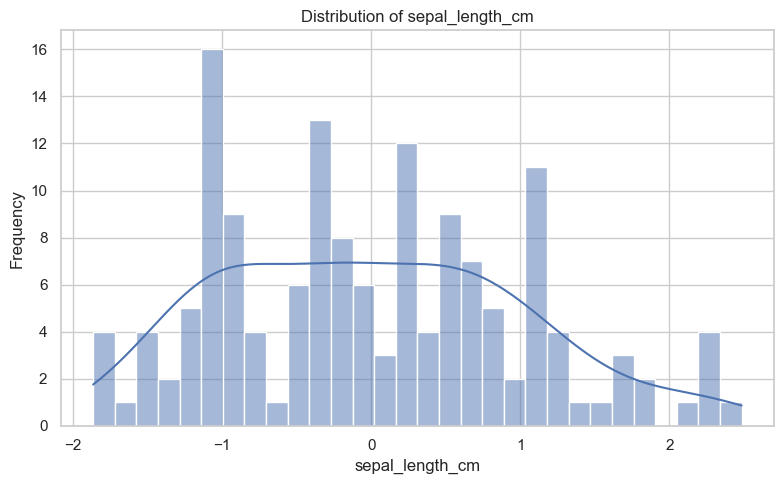

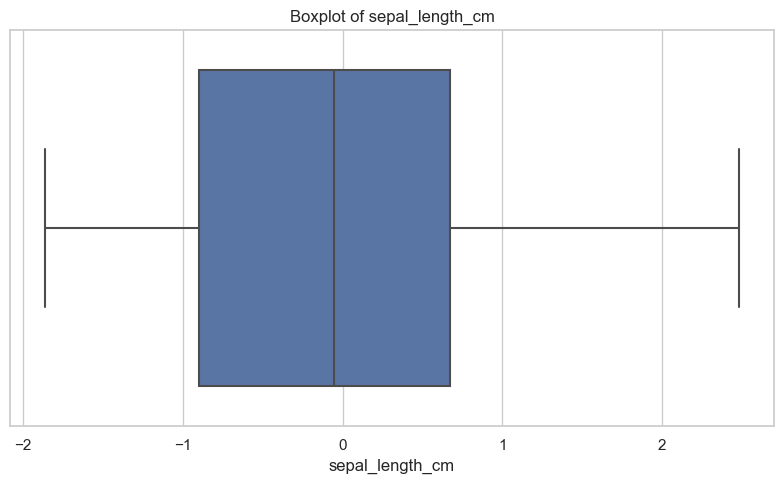

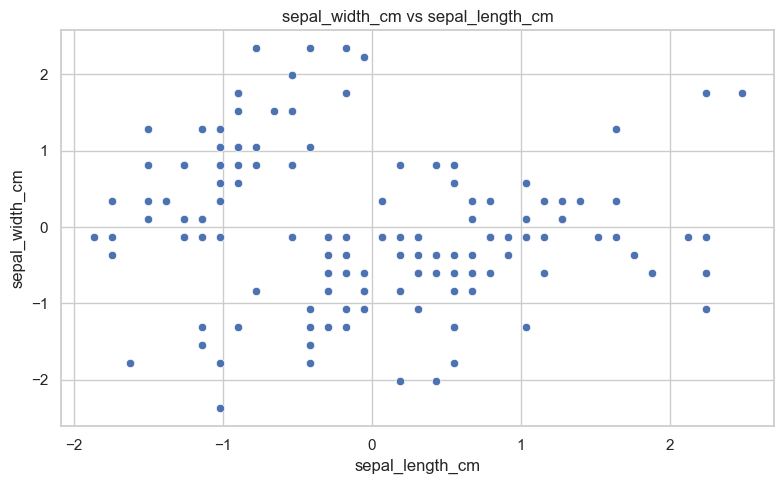

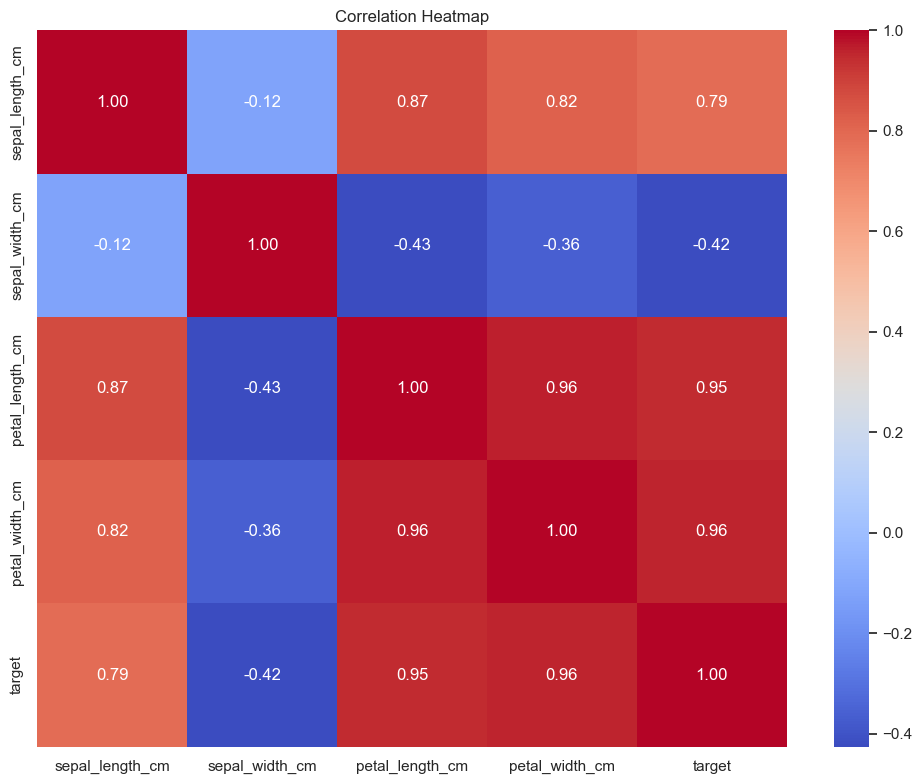

In [4]:
# Test run
if __name__ == "__main__":
    FILE_PATH = "cleaned_dataset.csv"

    try:
        df = load_data(FILE_PATH)

        info = get_basic_info(df)

        print("=" * 60)
        print("BASIC INFO")
        print("=" * 60)
        print("Shape:", info["shape"])
        print("\nColumns:")
        print(info["columns"])
        print("\nData types:")
        print(info["dtypes"])

        print("\n" + "=" * 60)
        print("MISSING VALUE SUMMARY")
        print("=" * 60)
        print(missing_value_summary(df))

        print("\n" + "=" * 60)
        print("NUMERIC SUMMARY")
        print("=" * 60)
        num_summary = numeric_summary(df)
        if not num_summary.empty:
            print(num_summary)
        else:
            print("No numeric columns found.")

        print("\n" + "=" * 60)
        print("CATEGORICAL SUMMARY")
        print("=" * 60)
        cat_summary = categorical_summary(df)
        if cat_summary:
            for col, summary in cat_summary.items():
                print(f"\n{col}:")
                print(summary)
        else:
            print("No categorical columns found.")

        numeric_cols = get_numeric_columns(df)
        categorical_cols = get_categorical_columns(df)

        # Example plots
        if numeric_cols:
            plot_histogram(df, numeric_cols[0], show=True)
            plot_boxplot(df, numeric_cols[0], show=True)

        if categorical_cols:
            plot_countplot(df, categorical_cols[0], show=True)

        if len(numeric_cols) >= 2:
            plot_scatter(df, numeric_cols[0], numeric_cols[1], show=True)
            plot_correlation_heatmap(df, show=True)

    except Exception as e:
        print(f"Error: {e}")